In [1]:
!pip install transformers torch matplotlib tqdm

import os
import json
import glob
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaConfig, RobertaTokenizer
from torch.optim import AdamW
from google.colab import drive

print(" Libraries imported successfully.")

 Libraries imported successfully.


In [2]:
drive.mount('/content/drive')

FOLDER_PATH = "/content/drive/MyDrive/dataMiningProject/CSI_Project/datasets"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f" Working on: {DEVICE}")

Mounted at /content/drive
 Working on: cuda


In [3]:
class MultiFileCodeDataset(Dataset):
    def __init__(self, folder_path, tokenizer, max_len=512):
        self.data = []
        self.tokenizer = tokenizer
        self.max_len = max_len

        file_list = glob.glob(os.path.join(folder_path, "*.jsonl"))
        for file_path in file_list:
            with open(file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    try: self.data.append(json.loads(line))
                    except: continue

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        code_lines = item.get('lines', [])
        line_labels = item.get('label', [0] * len(code_lines))

        input_ids = []
        token_labels = []

        for i, line in enumerate(code_lines):
            label = line_labels[i] if i < len(line_labels) else 0
            line_tokens = self.tokenizer.encode(line, add_special_tokens=False)
            input_ids.extend(line_tokens)
            token_labels.extend([label] * len(line_tokens))

        input_ids = input_ids[:self.max_len - 2]
        token_labels = token_labels[:self.max_len - 2]

        final_ids = [self.tokenizer.cls_token_id] + input_ids + [self.tokenizer.sep_token_id]
        final_labels = [0] + token_labels + [0]

        # Padding
        padding_len = self.max_len - len(final_ids)
        final_ids += [self.tokenizer.pad_token_id] * padding_len
        final_labels += [0] * padding_len

        attention_mask = [1] * (self.max_len - padding_len) + [0] * padding_len

        return {
            'input_ids': torch.tensor(final_ids),
            'attention_mask': torch.tensor(attention_mask),
            'labels': torch.tensor(final_labels, dtype=torch.float)
        }

In [4]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets, mask):
        ins = inputs.view(-1)
        tgs = targets.view(-1).float()
        mask = mask.view(-1) == 1

        ins, tgs = ins[mask], tgs[mask]

        BCE_loss = nn.functional.binary_cross_entropy_with_logits(ins, tgs, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss

        return torch.mean(F_loss)

class HybridVulnerabilityModel(nn.Module):
    def __init__(self, model_name="microsoft/graphcodebert-base", donor_name="claudios/VulBERTa-MLP-D2A"):
        super().__init__()
        print(f" Initializing Dual-Core Hybrid Model (VulBERTa + GraphCodeBERT)...")

        self.encoder_vul = RobertaModel.from_pretrained(donor_name)
        self.encoder_graph = RobertaModel.from_pretrained(model_name)

        self.dropout = nn.Dropout(0.1)

        combined_hidden_size = self.encoder_vul.config.hidden_size + self.encoder_graph.config.hidden_size

        self.classifier = nn.Linear(combined_hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        out_vul = self.encoder_vul(input_ids, attention_mask=attention_mask).last_hidden_state
        out_graph = self.encoder_graph(input_ids, attention_mask=attention_mask).last_hidden_state
        combined_features = torch.cat((out_vul, out_graph), dim=-1)

        logits = self.classifier(self.dropout(combined_features)).squeeze(-1)

        return logits

In [5]:
tokenizer = RobertaTokenizer.from_pretrained("claudios/VulBERTa-MLP-D2A")
dataset = MultiFileCodeDataset(FOLDER_PATH, tokenizer)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

model = HybridVulnerabilityModel(
    model_name="microsoft/graphcodebert-base",
    donor_name="claudios/VulBERTa-MLP-D2A"
).to(DEVICE)


for param in model.encoder_vul.parameters():
    param.requires_grad = False
for param in model.encoder_graph.parameters():
    param.requires_grad = False

criterion = BinaryFocalLoss()
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

print("✅ Tokenizer size matched with Model weights. Ready to train!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

 Initializing Dual-Core Hybrid Model (VulBERTa + GraphCodeBERT)...


...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Tokenizer size matched with Model weights. Ready to train!


🚀 Starting Professional Training on cuda...


Epoch 1/10: 100%|██████████| 3278/3278 [15:57<00:00,  3.42it/s, loss=0.0033, avg_loss=0.0233]


✅ Milestone: Best Model Saved (Loss: 0.0233)


Epoch 2/10: 100%|██████████| 3278/3278 [16:10<00:00,  3.38it/s, loss=0.0165, avg_loss=0.0214]


✅ Milestone: Best Model Saved (Loss: 0.0214)


...

✅ Milestone: Best Model Saved (Loss: 0.0202)


Epoch 8/10: 100%|██████████| 3278/3278 [16:03<00:00,  3.40it/s, loss=0.0061, avg_loss=0.0201]


✅ Milestone: Best Model Saved (Loss: 0.0201)


Epoch 10/10: 100%|██████████| 3278/3278 [16:03<00:00,  3.40it/s, loss=0.0032, avg_loss=0.0199]


✅ Milestone: Best Model Saved (Loss: 0.0199)


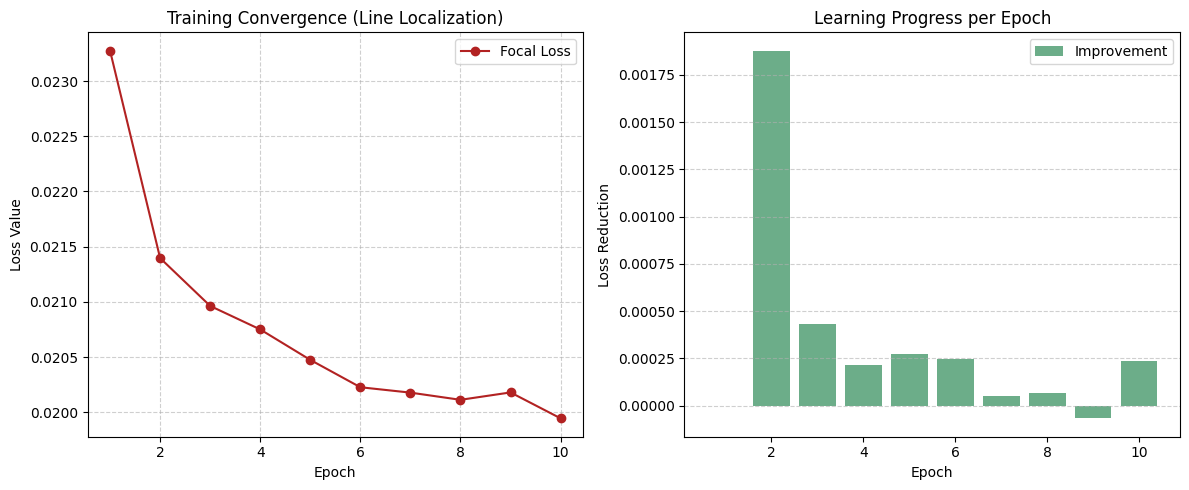

🏁 Training Complete! Best Loss achieved: 0.0199
💾 Your best weights are saved as 'best_localization_model.pt'


In [6]:
epochs = 10
best_loss = float('inf')
epoch_losses = []
learning_rates = []

print(f"🚀 Starting Professional Training on {DEVICE}...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in progress_bar:
        optimizer.zero_grad()

        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        targets = batch['labels'].to(DEVICE)

        logits = model(ids, mask)
        loss = criterion(logits, targets, mask)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()


        progress_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'avg_loss': f"{total_loss / (progress_bar.n + 1):.4f}"
        })


    avg_epoch_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_epoch_loss)


    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        torch.save(model.state_dict(), 'best_localization_model.pt')
        print(f"✅ Milestone: Best Model Saved (Loss: {best_loss:.4f})")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', linestyle='-', color='firebrick', label='Focal Loss')
plt.title('Training Convergence (Line Localization)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
loss_diff = np.diff(epoch_losses, prepend=epoch_losses[0])
plt.bar(range(1, len(epoch_losses) + 1), -loss_diff, color='seagreen', alpha=0.7, label='Improvement')
plt.title('Learning Progress per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss Reduction')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

print(f"🏁 Training Complete! Best Loss achieved: {best_loss:.4f}")
print("💾 Your best weights are saved as 'best_localization_model.pt'")

In [16]:
def check_my_code(code_snippet):

    model.eval()
    inputs = tokenizer(code_snippet, return_tensors="pt", truncation=True, padding='max_length', max_length=512).to(DEVICE)

    with torch.no_grad():
        logits = model(inputs['input_ids'], inputs['attention_mask'])
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()


    lines = code_snippet.strip().split('\n')
    tokens_per_line = []

    print(f"{'Line Content':<50} | {'Status'}")
    print("-" * 65)


    current_token_idx = 1
    for line in lines:
        line_tokens = tokenizer.encode(line, add_special_tokens=False)
        line_probs = probs[current_token_idx : current_token_idx + len(line_tokens)]

        max_prob = max(line_probs) if len(line_probs) > 0 else 0
        status = "🔴 VULNERABLE" if max_prob > 0.5 else "🟢 SAFE"

        print(f"{line[:48]:<50} | {status} ({max_prob:.2%})")
        current_token_idx += len(line_tokens)


my_test = """
void test(char *input) {
    char buf[8];
    strcpy(buf, input);
}
"""
check_my_code(my_test)


Line Content                                       | Status
-----------------------------------------------------------------
void test(char *input) {                           | 🔴 VULNERABLE (66.09%)
    char buf[8];                                   | 🔴 VULNERABLE (63.02%)
    strcpy(buf, input);                            | 🔴 VULNERABLE (72.36%)
}                                                  | 🔴 VULNERABLE (58.97%)


In [17]:
test2 = """
int main(int argc, char **argv) {
    char buffer[64];
    if (argc > 1) {
        strncpy(buffer, argv[1], sizeof(buffer) - 1); // كود سليم وآمن
        buffer[sizeof(buffer) - 1] = '\0';
    }
    return 0;
}
""";
check_my_code(test2)

Line Content                                       | Status
-----------------------------------------------------------------
int main(int argc, char **argv) {                  | 🟢 SAFE (44.71%)
    char buffer[64];                               | 🔴 VULNERABLE (54.70%)
    if (argc > 1) {                                | 🟢 SAFE (46.07%)
        strncpy(buffer, argv[1], sizeof(buffer)    | 🔴 VULNERABLE (59.95%)
        buffer[sizeof(buffer) - 1] = ' ';          | 🔴 VULNERABLE (56.23%)
    }                                              | 🟢 SAFE (44.25%)
    return 0;                                      | 🟢 SAFE (38.46%)
}                                                  | 🟢 SAFE (44.87%)


In [18]:
test3 = """
void process(int size) {
    int *array = (int *)malloc(size * sizeof(int)); // ممكن يحصل Overflow لو size كبير
    if (array) {
        // do something
        free(array);
    }
}
""";
check_my_code(test3)

Line Content                                       | Status
-----------------------------------------------------------------
void process(int size) {                           | 🟢 SAFE (45.75%)
    int *array = (int *)malloc(size * sizeof(int   | 🟢 SAFE (48.15%)
    if (array) {                                   | 🟢 SAFE (41.46%)
        // do something                            | 🟢 SAFE (40.10%)
        free(array);                               | 🟢 SAFE (45.39%)
    }                                              | 🟢 SAFE (42.28%)
}                                                  | 🟢 SAFE (46.26%)


In [19]:
test4 = """
void print_user_input(char *user_data) {
    printf(user_data); // ثغرة Format String
}
""";
check_my_code(test4)

Line Content                                       | Status
-----------------------------------------------------------------
void print_user_input(char *user_data) {           | 🟢 SAFE (48.07%)
    printf(user_data); // ثغرة Format String       | 🔴 VULNERABLE (55.08%)
}                                                  | 🟢 SAFE (47.40%)


In [20]:
import shutil
shutil.copy('best_localization_model.pt', '/content/drive/MyDrive/best_localization_model.pt')
print("✅ Done! ")

✅ Done! 


In [21]:
test_python_1 = """
def calculate_area(user_input):
    # ثغرة خطيرة جداً بتسمح بتنفيذ أي كود
    result = eval(user_input)
    return result
"""
check_my_code(test_python_1)

Line Content                                       | Status
-----------------------------------------------------------------
def calculate_area(user_input):                    | 🟢 SAFE (48.87%)
    # ثغرة خطيرة جداً بتسمح بتنفيذ أي كود          | 🟢 SAFE (49.69%)
    result = eval(user_input)                      | 🔴 VULNERABLE (50.83%)
    return result                                  | 🟢 SAFE (43.30%)


In [22]:
test_python_2 = """
import os

def ping_host(hostname):
    # خطر: ممكن المستخدم يكتب 'google.com; rm -rf /'
    os.system("ping -c 1 " + hostname)
"""
check_my_code(test_python_2)

Line Content                                       | Status
-----------------------------------------------------------------
import os                                          | 🟢 SAFE (42.34%)
                                                   | 🟢 SAFE (0.00%)
def ping_host(hostname):                           | 🔴 VULNERABLE (50.32%)
    # خطر: ممكن المستخدم يكتب 'google.com; rm -r   | 🟢 SAFE (49.62%)
    os.system("ping -c 1 " + hostname)             | 🔴 VULNERABLE (54.71%)


In [23]:
test_python_3 = """
import pickle

def load_user_settings(data):
    # ثغرة قاتلة: الـ unpickling لبيانات غير معروفة
    settings = pickle.loads(data)
    return settings
"""
check_my_code(test_python_3)

Line Content                                       | Status
-----------------------------------------------------------------
import pickle                                      | 🔴 VULNERABLE (50.57%)
                                                   | 🟢 SAFE (0.00%)
def load_user_settings(data):                      | 🟢 SAFE (49.39%)
    # ثغرة قاتلة: الـ unpickling لبيانات غير معر   | 🔴 VULNERABLE (51.59%)
    settings = pickle.loads(data)                  | 🔴 VULNERABLE (53.47%)
    return settings                                | 🟢 SAFE (42.00%)


In [24]:
test_python_4 = """
import ast

def safe_calculate(user_input):
    # ده كود سليم وآمن تماماً في بايثون
    result = ast.literal_eval(user_input)
    return result
"""
check_my_code(test_python_4)

Line Content                                       | Status
-----------------------------------------------------------------
import ast                                         | 🟢 SAFE (41.34%)
                                                   | 🟢 SAFE (0.00%)
def safe_calculate(user_input):                    | 🔴 VULNERABLE (50.73%)
    # ده كود سليم وآمن تماماً في بايثون            | 🟢 SAFE (46.55%)
    result = ast.literal_eval(user_input)          | 🔴 VULNERABLE (53.15%)
    return result                                  | 🟢 SAFE (46.47%)
